保存结果说明（所有文件都在你指定的文件夹）
路径：/home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/zhibiao/S3RL
文件名	                        格式	                         内容
S3RL_prediction_labels.csv	    CSV	                    空间位点条形码 + 预测标签 + 真实标签
S3RL_pred_labels.npy	        NPY	                    纯预测标签（和官方输出格式一致）
evaluation_metrics.txt	        TXT	                    ARI 评估指标
S3RL_trained_result.h5ad	    h5ad	                完整训练结果（可重复加载分析）
S3RL_visualization.png	        PNG	                    空间聚类可视化图

ground_truth

Training the S3RL model:   0%|          | 0/1500 [00:00<?, ?it/s]/home/zhangjunyi/anaconda3/envs/S3RL/lib/python3.7/site-packages/torch/autograd/__init__.py:175: UserWarning: An output with one or more elements was resized since it had shape [1, 32, 32], which does not match the required output shape [1, 1, 32, 32]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at  ../aten/src/ATen/native/Resize.cpp:17.)
  allow_unreachable=True, accumulate_grad=True)  # Calls into the C++ engine to run the backward pass
Training the S3RL model:   0%|          | 1/1500 [00:05<2:25:05,  5.81s/it]/home/zhangjunyi/anaconda3/envs/S3RL/lib/python3.7/site-packages/torch/nn/utils/parametrizations.py:83: UserWarning: An output with one or more elements was resized since it had shape [1, 16, 16], which does not matc

Reached the tolerance, early stop training at epoch 1241
ARI is 0.6341791786409978


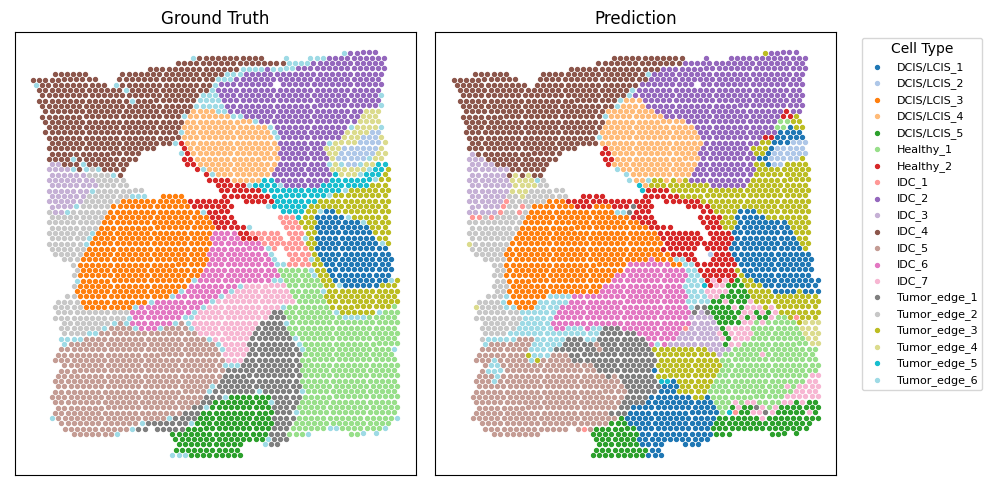

In [4]:
# --------------- 严格遵循官方教程代码 ---------------
import scanpy as sc
import os
import cv2
from S3RL.process_data import process_data
import pandas as pd
import numpy as np

# 路径配置（你的本地路径）
path = '/home/zhangjunyi/xiangmu/S3RL-main/Data'
dataset = 'Human_Breast_Cancer'
id = ''
knn = 5
pixel_size = 10
path_semantic_fea = '/home/zhangjunyi/xiangmu/S3RL-main/Data'

# 1. 读取并预处理数据
adata = sc.read_h5ad(os.path.join(path, dataset, id, 'sampledata.h5ad'))
adata.var_names_make_unique()

sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000, check_values=False)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

Ann_df = pd.read_csv(os.path.join(path, dataset, id, 'annotation.txt'), sep='\t', header=None, index_col=0)
Ann_df.columns = ['Ground Truth']
drop = Ann_df.loc[adata.obs_names, 'Ground Truth'].isna()
adata = adata[~drop]
adata = adata[:, adata.var['highly_variable']]

image = cv2.imread(os.path.join(path, dataset, id, 'spatial/tissue_hires_image.png'))
semantic_fea = np.load(os.path.join(path_semantic_fea, dataset, id, 'img_emb.npy'))

adata = process_data(adata, image, pixel=pixel_size, knn=knn, semantic_fea=semantic_fea)

# 2. 模型训练
from S3RL.model import S3RL
import yaml
import torch
from sklearn.metrics import adjusted_rand_score

device = torch.device("cuda:0")
C = len(set(Ann_df[Ann_df['Ground Truth'].notna()]['Ground Truth'].values.tolist()))
cfg_path = '/home/zhangjunyi/xiangmu/S3RL-main/Best_cfg'
with open(os.path.join(cfg_path, dataset, dataset+'.yaml'), 'r') as f:
    cfg = yaml.safe_load(f)

model = S3RL(adata, n_clu=C, device=device,** cfg)
adata = model.train()

# 3. 计算评估指标
adata.obs['Ground Truth'] = Ann_df.loc[adata.obs_names, 'Ground Truth']
ground_truth = adata.obs['Ground Truth'].astype('category').cat.codes.values
ari_score = adjusted_rand_score(ground_truth, adata.obs['pred'])
print('ARI is', ari_score)

# ===================== 【核心：保存结果到你指定的路径】 =====================
# 定义保存根路径
save_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/zhibiao/S3RL"
os.makedirs(save_dir, exist_ok=True)  # 自动创建文件夹

# 1. 保存预测的空间划分标签（CSV格式，方便查看）
pred_df = pd.DataFrame({
    "barcode": adata.obs_names,
    "pred_label": adata.obs['pred'].values,
    "ground_truth": adata.obs['Ground Truth'].values
})
pred_df.to_csv(os.path.join(save_dir, "S3RL_prediction_labels.csv"), index=False)

# 2. 保存预测标签为npy格式（和官方输出一致）
np.save(os.path.join(save_dir, "S3RL_pred_labels.npy"), adata.obs['pred'].values)

# 3. 保存评估指标（ARI）
with open(os.path.join(save_dir, "evaluation_metrics.txt"), "w", encoding="utf-8") as f:
    f.write(f"Adjusted Rand Index (ARI): {ari_score}\n")

# 4. 保存训练后的adata对象（包含所有结果，可重复加载）
adata.write_h5ad(os.path.join(save_dir, "S3RL_trained_result.h5ad"))

# 5. 保存可视化图片
import matplotlib
from S3RL.tools import hungarian_match
import matplotlib.pyplot as plt

label_pred = hungarian_match(ground_truth, adata.obs['pred'])
label_dict = dict(zip(ground_truth, adata.obs['Ground Truth'].values))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
colors = np.vstack([np.array(matplotlib.colormaps['tab20'].colors),
                    np.array(matplotlib.colormaps['tab20b'].colors),
                    np.array(matplotlib.colormaps['tab20c'].colors)])

for i in set(ground_truth):
    axs[0].scatter(adata.obsm['spatial'][ground_truth==i, 0], adata.obsm['spatial'][ground_truth==i, 1], color=colors[i], s=8)
    axs[1].scatter(adata.obsm['spatial'][label_pred==i, 0], adata.obsm['spatial'][label_pred==i, 1], color=colors[i], s=8, label=label_dict[i])

axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title='Cell Type', title_fontsize=10)
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[0].set_title('Ground Truth')
axs[1].set_title('Prediction')

# 保存图片
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "S3RL_visualization.png"), dpi=300, bbox_inches='tight')
plt.show()

annot_type

Training the S3RL model:   0%|          | 0/1500 [00:00<?, ?it/s]/home/zhangjunyi/anaconda3/envs/S3RL/lib/python3.7/site-packages/torch/autograd/__init__.py:175: UserWarning: An output with one or more elements was resized since it had shape [1, 32, 32], which does not match the required output shape [1, 1, 32, 32]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at  ../aten/src/ATen/native/Resize.cpp:17.)
  allow_unreachable=True, accumulate_grad=True)  # Calls into the C++ engine to run the backward pass
Training the S3RL model:   0%|          | 1/1500 [00:00<03:17,  7.60it/s]/home/zhangjunyi/anaconda3/envs/S3RL/lib/python3.7/site-packages/torch/nn/utils/parametrizations.py:83: UserWarning: An output with one or more elements was resized since it had shape [1, 16, 16], which does not match 

Reached the tolerance, early stop training at epoch 793


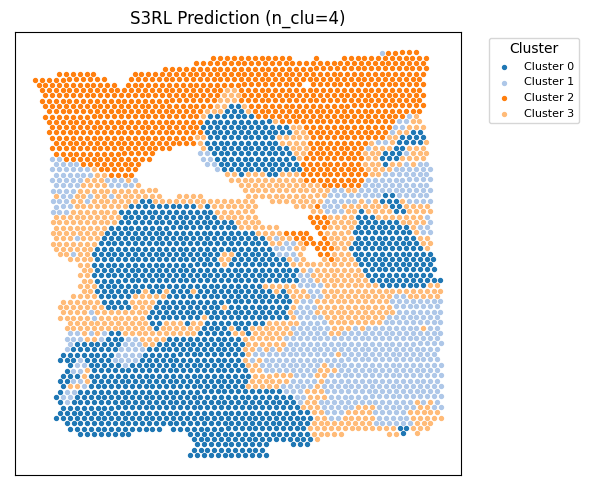

In [8]:
# --------------- 严格遵循官方教程代码 | 无注释 | 聚类数=4 | 纯预测 ---------------
import scanpy as sc
import os
import cv2
from S3RL.process_data import process_data
import pandas as pd
import numpy as np

# 路径配置（你的本地路径）
path = '/home/zhangjunyi/xiangmu/S3RL-main/Data'
dataset = 'Human_Breast_Cancer'
id = ''
knn = 5
pixel_size = 10
path_semantic_fea = '/home/zhangjunyi/xiangmu/S3RL-main/Data'

# 1. 读取并预处理数据（官方原版，无任何修改）
adata = sc.read_h5ad(os.path.join(path, dataset, id, 'sampledata.h5ad'))
adata.var_names_make_unique()

sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000, check_values=False)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# 【删除所有注释/真实标签代码】
adata = adata[:, adata.var['highly_variable']]

# 读取图像和图像特征（官方原版）
image = cv2.imread(os.path.join(path, dataset, id, 'spatial/tissue_hires_image.png'))
semantic_fea = np.load(os.path.join(path_semantic_fea, dataset, id, 'img_emb.npy'))

adata = process_data(adata, image, pixel=pixel_size, knn=knn, semantic_fea=semantic_fea)

# 2. 模型训练（核心修改：固定聚类数=4，无注释）
from S3RL.model import S3RL
import yaml
import torch

device = torch.device("cuda:0")
# 【关键：手动指定聚类数目为4】
n_clusters = 4  
cfg_path = '/home/zhangjunyi/xiangmu/S3RL-main/Best_cfg'
with open(os.path.join(cfg_path, dataset, dataset+'.yaml'), 'r') as f:
    cfg = yaml.safe_load(f)

# 初始化模型，n_clu=4
model = S3RL(adata, n_clu=n_clusters, device=device, **cfg)
# 训练模型，生成聚类标签
adata = model.train()

# ===================== 保存结果到指定路径 =====================
save_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/zhibiao/Human_breast_cancer_ViHBC/S3RL/annot_type"
os.makedirs(save_dir, exist_ok=True)

# 1. 保存预测的聚类标签（CSV）
pred_df = pd.DataFrame({
    "barcode": adata.obs_names,
    "S3RL_pred_label": adata.obs['pred'].values  # 仅保留预测标签
})
pred_df.to_csv(os.path.join(save_dir, "S3RL_prediction_labels.csv"), index=False)

# 2. 保存预测标签为npy格式（官方格式）
np.save(os.path.join(save_dir, "S3RL_pred_labels.npy"), adata.obs['pred'].values)

# 3. 保存训练后的adata对象
adata.write_h5ad(os.path.join(save_dir, "S3RL_trained_result.h5ad"))

# ===================== 可视化：仅展示S3RL预测聚类结果 =====================
import matplotlib
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
colors = np.vstack([np.array(matplotlib.colormaps['tab20'].colors),
                    np.array(matplotlib.colormaps['tab20b'].colors),
                    np.array(matplotlib.colormaps['tab20c'].colors)])

# 绘制预测的空间聚类结果
pred_labels = adata.obs['pred'].values
for i in set(pred_labels):
    ax.scatter(adata.obsm['spatial'][pred_labels==i, 0], 
               adata.obsm['spatial'][pred_labels==i, 1], 
               color=colors[i], s=8, label=f"Cluster {i}")

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title='Cluster', title_fontsize=10)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('S3RL Prediction (n_clu=4)')

# 保存图片
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "S3RL_visualization.png"), dpi=300, bbox_inches='tight')
plt.show()

In [1]:
# ===================== 多指标综合计算：ARI + F1 + ASW + DBI + Moran's I + SS-C(NA) =====================
# 核心：直接加载已保存的S3RL结果，不重新训练模型！
import pandas as pd
import numpy as np
import scanpy as sc
import squidpy as sq
from sklearn.metrics import (
    adjusted_rand_score,
    f1_score,
    silhouette_score,
    davies_bouldin_score
)
from sklearn.preprocessing import LabelEncoder
import os
import warnings
warnings.filterwarnings('ignore')

# ================ 1. 路径配置（完全沿用你的路径） ================
annot_path = "/home/zhangjunyi/xiangmu/S3RL-main/Data/Human_Breast_Cancer/annot_type.txt"
save_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/zhibiao/Human_breast_cancer_ViHBC/S3RL/annot_type"
adata_path = os.path.join(save_dir, "S3RL_trained_result.h5ad")  # 已保存的训练结果

# ================ 2. 加载已训练好的S3RL结果（关键：不重训！） ================
print("🔄 正在加载已保存的S3RL训练结果...")
adata = sc.read_h5ad(adata_path)  # 直接加载，跳过模型训练

# ================ 3. 对齐真实标签 ================
annot_df = pd.read_csv(annot_path, sep="\t", header=None, index_col=0)
annot_df.columns = ["Ground_Truth"]
common_barcodes = adata.obs_names.intersection(annot_df.index)
adata = adata[common_barcodes]
annot_aligned = annot_df.loc[common_barcodes]

# 标签编码
le = LabelEncoder()
ground_truth = le.fit_transform(annot_aligned["Ground_Truth"].values)
pred_labels = adata.obs["pred"].values

# ================ 4. 计算所有6个指标 ================
results = []
print("\n📊 开始计算多指标评估...")

# 1. ARI
ari = adjusted_rand_score(ground_truth, pred_labels)
results.append({
    "Metric Name": "Adjusted Rand Index",
    "Abbreviation": "ARI",
    "Value": round(ari, 4),
    "Ideal Trend": "Closer to 1",
    "Evaluation Dimension": "Macro Boundary (Supervised)"
})
print(f"✅ ARI = {ari:.4f}")

# 2. F1-Score (加权多分类F1，适配空间聚类)
f1 = f1_score(ground_truth, pred_labels, average='weighted')
results.append({
    "Metric Name": "F1-Score",
    "Abbreviation": "F1",
    "Value": round(f1, 4),
    "Ideal Trend": "Closer to 1",
    "Evaluation Dimension": "Macro Boundary (Supervised)"
})
print(f"✅ F1 = {f1:.4f}")

# 3. ASW 平均轮廓系数（基于S3RL高变基因表达）
X = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
asw = silhouette_score(X, pred_labels)
results.append({
    "Metric Name": "Average Silhouette Width",
    "Abbreviation": "ASW",
    "Value": round(asw, 4),
    "Ideal Trend": "Closer to 1",
    "Evaluation Dimension": "Micro Pureness (Unsupervised)"
})
print(f"✅ ASW = {asw:.4f}")

# 4. SS-C 耦合分数轮廓系数（S3RL无代谢耦合分数 → 标记NA）
ss_c = np.nan
results.append({
    "Metric Name": "Silhouette Score on Coupling Scores",
    "Abbreviation": "SS-C",
    "Value": "NA",
    "Ideal Trend": "Closer to 1",
    "Evaluation Dimension": "Micro Pureness (Unsupervised)"
})
print("⚠️ SS-C = NA (S3RL无代谢耦合分数特征)")

# 5. DBI 戴维斯-布尔丁指数
dbi = davies_bouldin_score(X, pred_labels)
results.append({
    "Metric Name": "Davies-Bouldin Index",
    "Abbreviation": "DBI",
    "Value": round(dbi, 4),
    "Ideal Trend": "Closer to 0",
    "Evaluation Dimension": "Micro Pureness (Unsupervised)"
})
print(f"✅ DBI = {dbi:.4f}")

# 6. Moran's I 空间自相关指数
sq.gr.spatial_neighbors(adata, coord_type='generic', n_neighs=6)
adata.obs['pred_encoded'] = pred_labels
sq.gr.moran_i(adata, 'pred_encoded', n_perms=100)
moran_i = adata.uns['moranI']['I'][0]
results.append({
    "Metric Name": "Moran's Index",
    "Abbreviation": "Moran's I",
    "Value": round(moran_i, 4),
    "Ideal Trend": "Closer to 1 (>0)",
    "Evaluation Dimension": "Spatial Topology (Physical)"
})
print(f"✅ Moran's I = {moran_i:.4f}")

# ================ 5. 保存为你指定格式的CSV ================
df = pd.DataFrame(results)
csv_path = os.path.join(save_dir, "S3RL_evaluation_metrics.csv")
df.to_csv(csv_path, index=False, encoding="utf-8-sig")

# ================ 6. 额外保存对齐标签（保留原有功能） ================
result_csv = pd.DataFrame({
    "barcode": adata.obs_names,
    "S3RL_pred_label": pred_labels,
    "Ground_Truth_annot_type": annot_aligned["Ground_Truth"].values
})
result_csv.to_csv(os.path.join(save_dir, "S3RL_pred_vs_groundtruth.csv"), index=False)

# ================ 7. 输出完成信息 ================
print("\n" + "="*60)
print("🎉 所有指标计算完成！")
print(f"📄 指标表格保存：{csv_path}")
print(f"📄 标签对齐文件：{os.path.join(save_dir, 'S3RL_pred_vs_groundtruth.csv')}")
print("="*60)

# 打印结果预览
print("\n📋 指标结果预览：")
print(df.to_string(index=False))

ModuleNotFoundError: No module named 'squidpy'

In [9]:
#计算ARI
# ===================== 接续运行：计算ARI + 保存对齐标签CSV =====================
import pandas as pd
import numpy as np
from sklearn.metrics import adjusted_rand_score
import os

# 1. 定义路径
annot_path = "/home/zhangjunyi/xiangmu/S3RL-main/Data/Human_Breast_Cancer/annot_type.txt"
save_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/zhibiao/S3RL/annot_type"

# 2. 读取真实注释文件
annot_df = pd.read_csv(annot_path, sep="\t", header=None, index_col=0)
annot_df.columns = ["Ground_Truth"]

# 3. 对齐样本（仅保留共有 barcode，避免报错）
common_barcodes = adata.obs_names.intersection(annot_df.index)
adata_aligned = adata[common_barcodes]
annot_aligned = annot_df.loc[common_barcodes]

# 4. 生成数值化标签（计算ARI必须用数字）
ground_truth = annot_aligned["Ground_Truth"].astype("category").cat.codes.values
pred_labels = adata_aligned.obs["pred"].values

# 5. 计算ARI
ari = adjusted_rand_score(ground_truth, pred_labels)
print(f"✅ S3RL 聚类 ARI = {ari:.6f}")

# 6. 保存【对齐后的标签总表】CSV（barcode+预测标签+真实标签）
result_csv = pd.DataFrame({
    "barcode": adata_aligned.obs_names,
    "S3RL_pred_label": pred_labels,
    "Ground_Truth_annot_type": annot_aligned["Ground_Truth"].values
})
result_csv.to_csv(os.path.join(save_dir, "S3RL_pred_vs_groundtruth.csv"), index=False)

# 7. 保存ARI指标到文本文件
with open(os.path.join(save_dir, "ARI_result.txt"), "w", encoding="utf-8") as f:
    f.write(f"Adjusted Rand Index (ARI): {ari}\n")

print(f"\n📄 对齐标签表已保存：{os.path.join(save_dir, 'S3RL_pred_vs_groundtruth.csv')}")
print(f"📄 ARI 结果已保存：{os.path.join(save_dir, 'ARI_result.txt')}")

✅ S3RL 聚类 ARI = 0.216038

📄 对齐标签表已保存：/home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/zhibiao/S3RL/annot_type/S3RL_pred_vs_groundtruth.csv
📄 ARI 结果已保存：/home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/zhibiao/S3RL/annot_type/ARI_result.txt
